# Causal discovery for test data


In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as plt
from castle.algorithms import PC
from castle.common import GraphDAG

c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\algorithms\pc\pc.py:124: SyntaxWarning: invalid escape sequence '\{'
  """
2026-07-22 11:49:31,754 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\backend\__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\algorithms\gradient\gran_dag\torch\gran_dag.py:497: SyntaxWarning: invalid escape sequence '\p'
  """
2026-07-22 11:49:33,595 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\algorithms\__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


Load data:

In [3]:
df = pd.read_csv ("gen_data_1000.csv")

Run the PC algorithm for causal discovery on the data:

In [4]:
pc = PC()

pc.learn(df)

View the numbers in the matrix:

In [5]:
pc.causal_matrix

Tensor([[0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0]])

Plot the matrix:

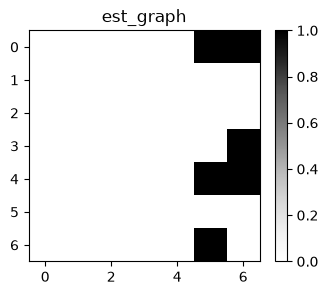

In [6]:
GraphDAG(est_dag=pc.causal_matrix)

Get edges out of the matrix:

In [7]:
import utils_causal

nodes = ['A', 'B', 'C', 'D', 'E', 'outcome', 'treatment']
labels = nodes

nodes_labels = [(n, n) for n in nodes]

edges = []
for i, start_node in enumerate(nodes):
    for j, end_node in enumerate(nodes):
        if pc.causal_matrix[i, j] == 1:
            edges.append((start_node, end_node))

c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Make the causal model and view the network graph:

2026-07-22 11:49:36,021 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-07-22 11:49:36,024 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


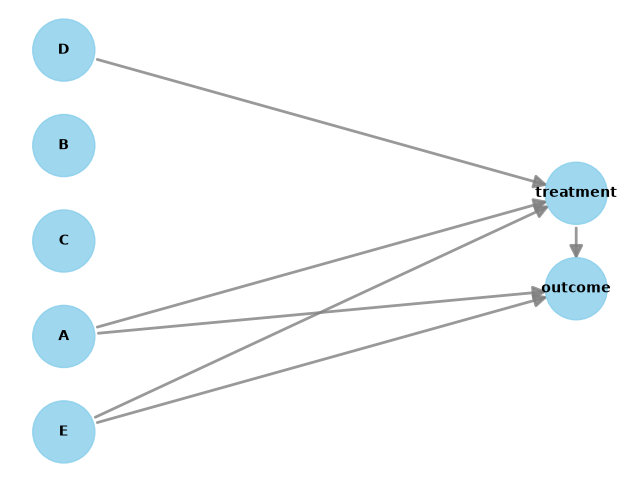

In [8]:
model_test = utils_causal.make_causalmodel_object(nodes_labels, edges)
model_test.view_model()

Based on the gen dataset, our prediction suggested a positive relationship between:
* A and outcome
* A and treatment
* D and outcome 
* D and treatment
* treatment and outcome 


Based on calculations from the model, there appears to be a relationship between:
* A and outcome
* A and treatment
* E and outcome
* E and treatment
* D and treatment
* treatment and outcome

2026-07-22 11:49:36,126 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-07-22 11:49:36,129 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


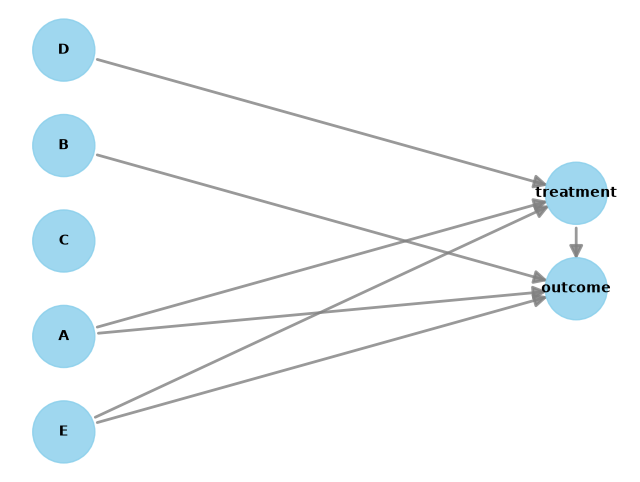

In [9]:
import utils_causal

nodes = ['A', 'B', 'C', 'D', 'E', 'outcome', 'treatment']
labels = nodes

nodes_labels = [(n, n) for n in nodes]

edges = [
    ('A', 'treatment'),
    ('A', 'outcome'),
    ('B','outcome'),
    ('D', 'treatment'),
    ('E', 'outcome'),
    ('E', 'treatment'),
    ('treatment','outcome')
]

model_test = utils_causal.make_causalmodel_object(nodes_labels, edges)
model_test.view_model()

The graph above has been designed using the actual causal test data. It shows a relationship between the following variables:
* A and treatment (0.45)
* A and outcome (0.33)
* B and outcome (0.02)
* D and treatment (1.32)
* E and treatment (0.15)
* E and outcome (0.39)
* treatment and outcome (5.0)

The equations used to formulate the data include:
* Treatment= Noise + 0.45 A + 0.15 E + 1.32 D
* Outcome= Noise + 5.0 treatment + 0.33 A + 0.39 E + 0.02 B

C had no link to the treatment and outcome

Where D has a 73% probability of being 1

Average treatment effect identified from data is 5.000349

This concludes that A and E are confounders, D is an instrument and B is an outcome modifier.

## Differences in the DAGs
We will be talking about 3 DAGs in this section:
* Predicition data (PD)
* Model calculation (MC)
* Real data (RD)

Across all three graphs the common link was the correct identification of the link between treatment and outcome. Additionally, the relationship between A with treatment and outcome as well as between D and treatment. 
### RD vs PD
* In the Real Data, D is an instrument. However, the PD incorrectly adds D's relationship with outcome, making it a confounder.
* While E is a critical confounder in RD, PD leaves it entirely.
* PD fails to capture the B-outcome relationship.

### RD vs MC
* The MC graph is highly accurate and captures nearly the entire true causal architecture. However, the model fails to capture the B-outcome relationship.
* The MC graph successfully captures A and E as true confounders.